In [2]:
import os
import numpy as np
import pandas as pd
import scipy
from scipy.stats import median_abs_deviation
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from tqdm import tqdm
import pyBigWig as pbw
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


# === PyTorch ===
import torch
from torch.utils.data import DataLoader


In [3]:
%run /home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/Common.ipynb
params.read("/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini")

['/home/sabramov/projects/ENCODE4/ENCODE4_DHS/common/release_paths.ini']

In [4]:
import anndata as ad
import pandas as pd
import numpy as np
from genome_tools.data.anndata import read_zarr_backed
from genome_tools import GenomicInterval, VariantInterval, df_to_variant_intervals
from genome_tools.data.extractors import FastaExtractor, TabixExtractor

from vinson.utils.sequence_utils import one_hot_encode, get_iupac_char_from_alleles
from vinson.utils.helpers import replace_at
import logging

from vinson.utils.data_formatting import extract_data_from_h5
from vinson.utils.helpers import read_configs

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

# === Custom Fonts for Matplotlib ===
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]



In [5]:
import os
import sys
import random
import numpy as np
import anndata as ad
from argparse import ArgumentParser


import torch
import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor,
)

from vinson.utils.helpers import read_configs, save_config, generate_run_name
from vinson.utils.run import (
    datamodule_from_config,
    model_from_config,
    set_global_seed,
    set_worker_seed,
    init_multigpu_trainer,
    fit_model,
)

torch.set_float32_matmul_precision('high')

In [6]:
var_config_path = "/net/seq/data2/projects/mbrannon/variant_model_vinson/2026_01_19_wizardly_jang/run_config.yaml"
var_checkpoint = "/net/seq/data2/projects/mbrannon/variant_model_vinson/2026_01_19_wizardly_jang/checkpoints/last.ckpt"

reg_config_path = "/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/vinson_model/2025_11_04_trusting_goldwasser/run_config.yaml"
reg_checkpoint = "/net/seq/data2/projects/ENCODE4Plus/REGULOME/sequence_to_accessibility_model/vinson_model/2025_11_04_trusting_goldwasser/checkpoints/last.ckpt"

variant_file = "/net/seq/data2/projects/mbrannon/vinson/variant_train_adata_epochs_balanced_noambig.h5ad"
genotype_file = "/net/seq/data2/projects/sabramov/ENCODE4/dnase-wasp.v5/phasing/output/all_phased.bed.gz"
fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"


In [7]:
var_config = read_configs(var_config_path)
reg_config = read_configs(reg_config_path)

variant_model = model_from_config(var_config, checkpoint_path=var_checkpoint).eval()
reg_model = model_from_config(reg_config, checkpoint_path=reg_checkpoint).eval()

device = torch.device("cpu")
variant_model.to(device)
reg_model.to(device)


EmbedModel(
  (trunk): BassetTrunkEmbed(
    (layer1): Sequential(
      (0): Conv1d(4, 300, kernel_size=(19,), stride=(1,), padding=same)
      (1): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=3, stride=3, padding=1, dilation=1, ceil_mode=False)
    )
    (relu1): ReLU()
    (layer2): Sequential(
      (0): Conv1d(300, 200, kernel_size=(11,), stride=(1,), padding=same)
      (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=4, stride=4, padding=1, dilation=1, ceil_mode=False)
    )
    (relu2): ReLU()
    (layer3): Sequential(
      (0): Conv1d(200, 200, kernel_size=(7,), stride=(1,), padding=same)
      (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=4, stride=4, padding=1, dilation=1, ceil_mode=False)
    )
    (relu3): ReL

In [8]:
from vinson.utils.data_formatting import extract_data_from_train_anndata, extract_variant_data_from_anndata
from vinson.datasets.sequence import SequenceEmbedDataset, VariantEmbedDataset


In [9]:
dhs_split = "val"
full_adata = ad.read_h5ad(variant_file)
adata_val = full_adata[
    :,
    full_adata.varm["split_data"] == dhs_split,
]

In [26]:
full_data = extract_variant_data_from_anndata(adata_val, "epoch_3")


In [14]:
dataset = VariantEmbedDataset(
    data=full_data,
    fasta_file=fasta_file,
    genotype_file=genotype_file
)

val_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    drop_last=False,
)

NameError: name 'full_data' is not defined

In [28]:
from tqdm import tqdm

all_preds = []
all_targets = []

model = variant_model
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Running validation"):
        seq_ref = batch["ohe_seq_ref"].to(device)
        seq_alt = batch["ohe_seq_alt"].to(device)
        embed   = batch["embed"].to(device)

        targets = batch["lfc"].to(device)

        outputs = model(
            seq_ref=seq_ref,
            seq_alt=seq_alt,
            embed=embed,
        )

        preds = outputs.squeeze(-1)

        all_preds.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())


Running validation: 100%|██████████| 573/573 [03:49<00:00,  2.49it/s]


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)


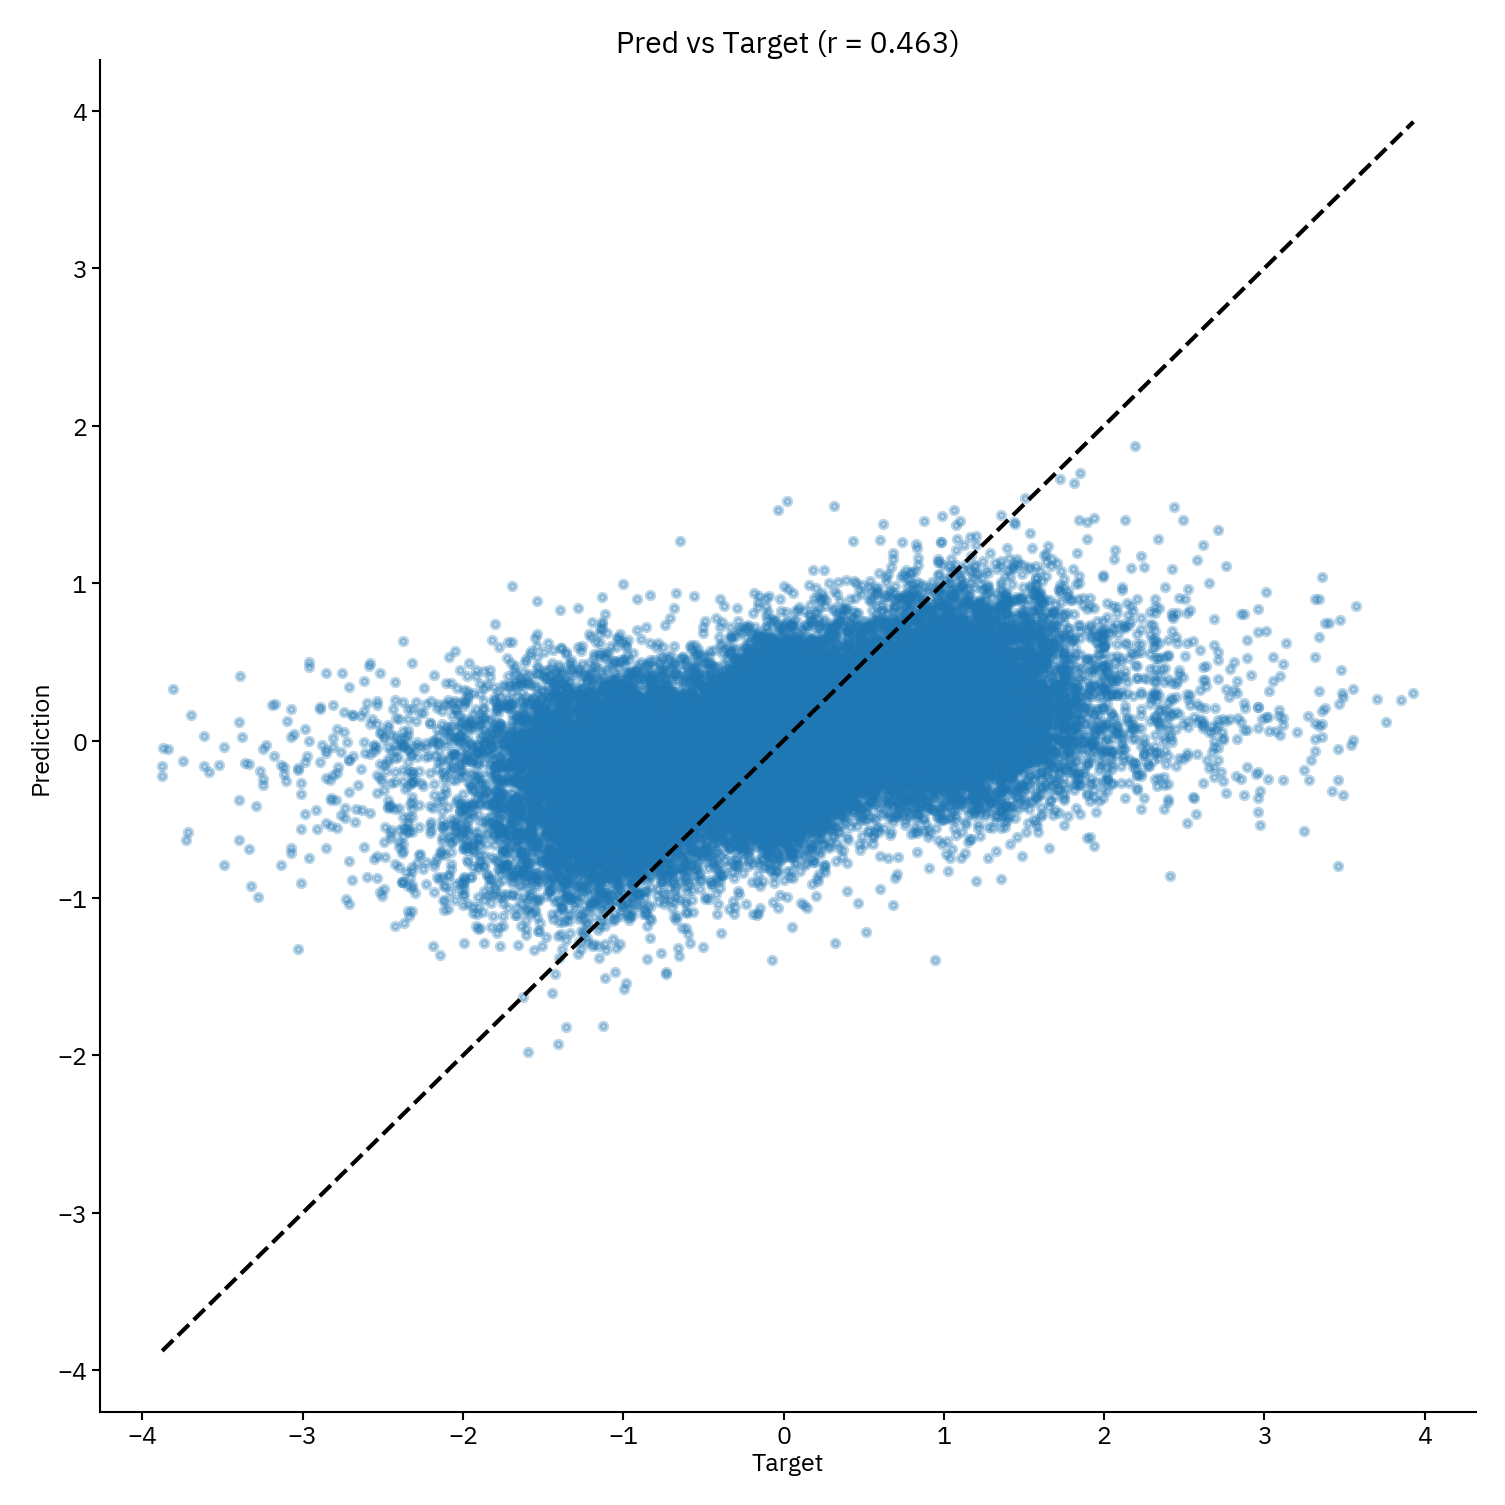

In [30]:
plt.figure(figsize=(5, 5))
plt.scatter(all_targets, all_preds, s=3, alpha=0.3)

# diagonal line
lims = [
    min(all_targets.min(), all_preds.min()),
    max(all_targets.max(), all_preds.max()),
]
plt.plot(lims, lims, 'k--', linewidth=1)

r, _ = pearsonr(all_targets, all_preds)

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title(f"Pred vs Target (r = {r:.3f})")
plt.tight_layout()
plt.show()


In [ ]:
#now look at lfc regular model vs variant

In [10]:
def to_tensor(x, device):
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        return x.to(device)
    return torch.as_tensor(x, device=device)


def predict_regular(batch, model):
    X_ref = to_tensor(batch["ohe_seq_ref"], device)
    X_alt = to_tensor(batch["ohe_seq_alt"], device)
    X_emb = to_tensor(batch.get("embed"), device)

    if X_ref.ndim == 2:
        X_ref = X_ref.unsqueeze(0)
        X_alt = X_alt.unsqueeze(0)
    if X_emb is not None and X_emb.ndim == 1:
        X_emb = X_emb.unsqueeze(0)

    with torch.no_grad():
        y_ref = model(X_ref, embed=X_emb).squeeze().cpu().numpy()
        y_alt = model(X_alt, embed=X_emb).squeeze().cpu().numpy()

    return y_ref, y_alt


def predict_variant(batch, model):
    X_ref = to_tensor(batch["ohe_seq_ref"], device)
    X_alt = to_tensor(batch["ohe_seq_alt"], device)
    X_emb = to_tensor(batch.get("embed"), device)

    if X_ref.ndim == 2:
        X_ref = X_ref.unsqueeze(0)
        X_alt = X_alt.unsqueeze(0)
    if X_emb is not None and X_emb.ndim == 1:
        X_emb = X_emb.unsqueeze(0)

    with torch.no_grad():
        y = model(X_ref, X_alt, X_emb).squeeze().cpu().numpy()

    return y


In [11]:
device = torch.device("cpu")

epochs = ["epoch_1", "epoch_2", "epoch_3"]

all_var_preds = []
all_reg_preds = []
all_lfc = []

for epoch in epochs:
    print(f"\nProcessing {epoch}...")

    # rebuild dataset for this epoch
    full_data = extract_variant_data_from_anndata(adata_val, epoch)

    dataset = VariantEmbedDataset(
        data=full_data,
        fasta_file=fasta_file,
        genotype_file=genotype_file
    )

    val_loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=1,
        pin_memory=True,
        drop_last=False,
    )

    variant_model.eval()
    reg_model.eval()

    with torch.no_grad():
        for batch in val_loader:
            # --- true target ---
            lfc = batch["lfc"].cpu().numpy()        # shape (B,)

            # --- variant model prediction ---
            y_var = predict_variant(batch, variant_model)   # (B,) or scalar

            # --- regular model predictions ---
            y_ref, y_alt = predict_regular(batch, reg_model)
            y_reg = y_ref - y_alt                    # (B,)

            # make sure shapes align
            y_var = np.atleast_1d(y_var)
            y_reg = np.atleast_1d(y_reg)
            lfc   = np.atleast_1d(lfc)

            all_var_preds.append(y_var)
            all_reg_preds.append(y_reg)
            all_lfc.append(lfc)

# stack everything
all_var_preds = np.concatenate(all_var_preds, axis=0)
all_reg_preds = np.concatenate(all_reg_preds, axis=0)
all_lfc       = np.concatenate(all_lfc, axis=0)

print("Final shapes:")
print("variant preds:", all_var_preds.shape)
print("regular preds:", all_reg_preds.shape)
print("lfc:", all_lfc.shape)



Processing epoch_1...

Processing epoch_2...

Processing epoch_3...
Final shapes:
variant preds: (109928,)
regular preds: (109928,)
lfc: (109928,)


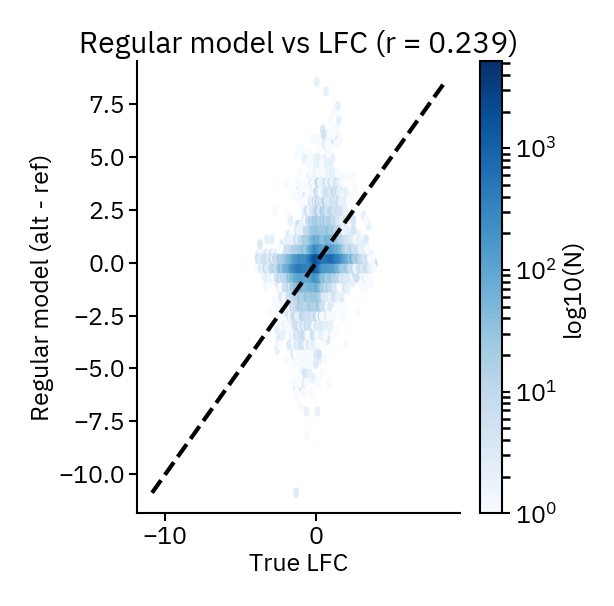

In [12]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))

hb = plt.hexbin(
    all_lfc,
    all_reg_preds,
    gridsize=75,   #increase for finer resolution
    bins="log" ,
    cmap="Blues"
)

lims = [
    min(all_lfc.min(), all_reg_preds.min()),
    max(all_lfc.max(), all_reg_preds.max()),
]
plt.plot(lims, lims, 'k--', linewidth=1)

r, _ = pearsonr(all_lfc, all_reg_preds)

plt.xlabel("True LFC")
plt.ylabel("Regular model (alt - ref)")
plt.title(f"Regular model vs LFC (r = {r:.3f})")

cb = plt.colorbar(hb)
cb.set_label("log10(N)")

plt.tight_layout()
plt.show()


In [13]:
all_reg_preds

array([-0.17675364,  0.06251156,  0.02170914, ...,  0.35924864,
        1.6654112 , -0.20954657], shape=(109928,), dtype=float32)

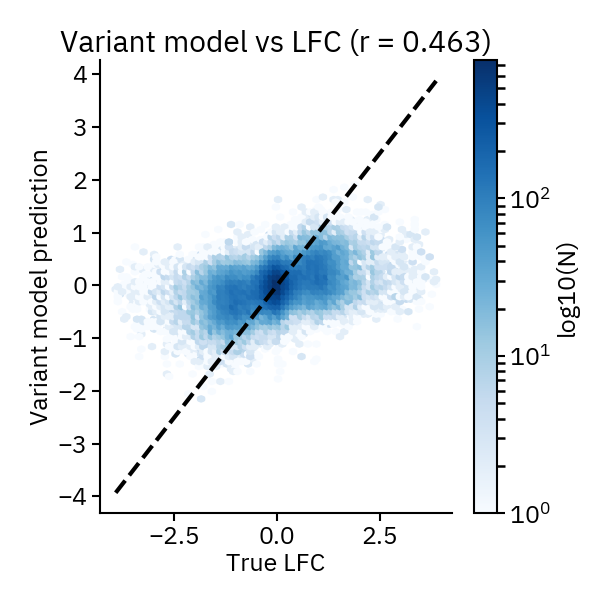

In [14]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

plt.figure(figsize=(2, 2))

hb = plt.hexbin(
    all_lfc,
    all_var_preds,
    gridsize=75,
    bins="log",
    cmap="Blues"
)

lims = [
    min(all_lfc.min(), all_var_preds.min()),
    max(all_lfc.max(), all_var_preds.max()),
]
plt.plot(lims, lims, 'k--', linewidth=1)

r, _ = pearsonr(all_lfc, all_var_preds)

plt.xlabel("True LFC")
plt.ylabel("Variant model prediction")
plt.title(f"Variant model vs LFC (r = {r:.3f})")

cb = plt.colorbar(hb)
cb.set_label("log10(N)")

plt.tight_layout()
plt.show()


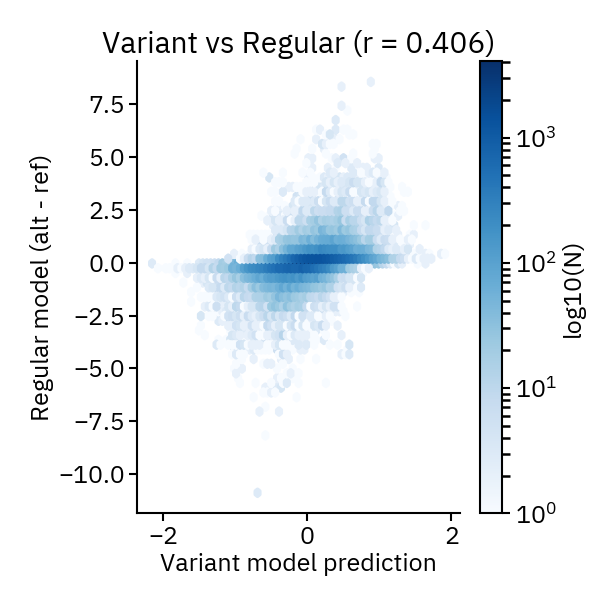

In [15]:
plt.figure(figsize=(2, 2))

hb = plt.hexbin(
    all_var_preds,
    all_reg_preds,
    gridsize=75,
    bins="log",
    cmap="Blues"
)

r, _ = pearsonr(all_var_preds, all_reg_preds)

plt.ylabel("Regular model (alt - ref)")
plt.xlabel("Variant model prediction")
plt.title(f"Variant vs Regular (r = {r:.3f})")

cb = plt.colorbar(hb)
cb.set_label("log10(N)")

plt.tight_layout()
plt.show()


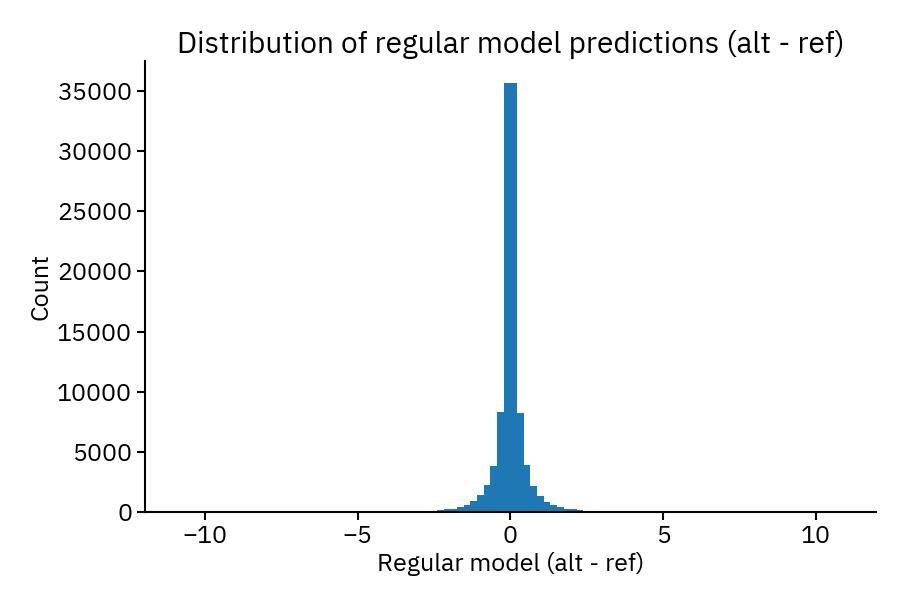

In [54]:
plt.figure(figsize=(3, 2))
plt.hist(all_reg_preds, bins=100)

plt.xlabel("Regular model (alt - ref)")
plt.ylabel("Count")
plt.title("Distribution of regular model predictions (alt - ref)")
plt.tight_layout()
plt.show()


In [16]:
#now look at variant specifically
#restart
#use full adta not just validation
full_data = extract_variant_data_from_anndata(full_adata, "epoch_1")


In [17]:
dataset = VariantEmbedDataset(
    data=full_data,
    fasta_file=fasta_file,
    genotype_file=genotype_file
)

val_loader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=False,
    num_workers=1,
    pin_memory=True,
    drop_last=False,
)

In [21]:
from tqdm import tqdm

model = variant_model
model.eval()


VariantEmbedModel(
  (trunk): BassetTrunkEmbed(
    (layer1): Sequential(
      (0): Conv1d(4, 300, kernel_size=(19,), stride=(1,), padding=same)
      (1): BatchNorm1d(300, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=3, stride=3, padding=1, dilation=1, ceil_mode=False)
    )
    (relu1): ReLU()
    (layer2): Sequential(
      (0): Conv1d(300, 200, kernel_size=(11,), stride=(1,), padding=same)
      (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=4, stride=4, padding=1, dilation=1, ceil_mode=False)
    )
    (relu2): ReLU()
    (layer3): Sequential(
      (0): Conv1d(200, 200, kernel_size=(7,), stride=(1,), padding=same)
      (1): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=4, stride=4, padding=1, dilation=1, ceil_mode=False)
    )
    (relu

In [ ]:
all_rows = []

model.eval()
with torch.no_grad():
    for batch in val_loader:
        seq_ref = batch["ohe_seq_ref"].to(device)
        seq_alt = batch["ohe_seq_alt"].to(device)
        embed   = batch["embed"].to(device)

        targets = batch["lfc"].to(device)

        outputs = model(
            seq_ref=seq_ref,
            seq_alt=seq_alt,
            embed=embed,
        )
        preds = outputs.squeeze(-1).cpu().numpy()
        targets = targets.cpu().numpy()

        # metadata (stay on CPU)
        sample_ids = batch["sample_id"]
        chroms     = batch["chrom"]
        poss       = batch["pos"].cpu().numpy()

        for i in range(len(preds)):
            all_rows.append({
                "sample_id": sample_ids[i],
                "chrom": chroms[i],
                "pos": poss[i],
                "lfc_true": targets[i],
                "lfc_pred": preds[i],
            })


In [ ]:
df = pd.DataFrame(all_rows)
obs = full_adata.obs

for col in ["extended_annotation"]:
    df[col] = df["sample_id"].map(obs[col])

In [ ]:
group_col = "extended_annotation"   # or "cell_type"
per_group_corr = (
    df
    .groupby(group_col)
    .apply(lambda x: pearsonr(x["lfc_true"], x["lfc_pred"])[0]
           if len(x) > 1 else np.nan)
    .reset_index(name="pearson_r")
)

per_group_corr.sort_values("pearson_r", ascending=False).head()
gb = (
    df
    .groupby(group_col)
    .agg(
        obs_lfc=("lfc_true", "mean"),
        pred_lfc=("lfc_pred", "mean"),
        n_variants=("lfc_true", "size"),
    )
    .reset_index()
)

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="lfc_true",
    y="lfc_pred",
    hue=group_col,
    alpha=0.3,
    s=10,
)

# overall Pearson
r_all, _ = pearsonr(df["lfc_true"], df["lfc_pred"])
plt.title(f"Variant LFC predictions vs observed\nOverall Pearson r={r_all:.3f}")

plt.xlabel("Observed LFC")
plt.ylabel("Predicted LFC")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
# merge Pearson into gb
gb_plot = gb.merge(per_group_corr, left_on=group_col, right_on=group_col)

# remove groups with 0 variants or NaN Pearson
gb_plot = gb_plot[(gb_plot["n_variants"] > 0) & (gb_plot["pearson_r"].notna())]

# sort by Pearson (descending)
gb_plot = gb_plot.sort_values("pearson_r", ascending=False)

# Vertical barplot: groups on x-axis
plt.figure(figsize=(10,5))
sns.barplot(
    data=gb_plot,
    x=group_col,
    y="pearson_r",
    palette="viridis"
)
plt.ylabel("Pearson r (predicted vs observed)")
plt.xlabel("Group")
plt.title("Variant LFC prediction quality by group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
# Count number of samples per annotation
sample_counts = (
    df[~df[group_col].str.contains("pluripotent", case=False, na=False)]
    .groupby(group_col)["sample_id"]
    .nunique()
    .reset_index(name="n_samples")
    .sort_values("n_samples", ascending=False)
)

print(sample_counts)



In [ ]:
#this is just a subset of the validation data separted by group not a whole cell prediction
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Exclude annotations with no variants or 'pluripotent'
df_plot = df[~df[group_col].str.contains("pluripotent", case=False, na=False)].copy()
df_plot = df_plot[df_plot["lfc_true"].notna() & df_plot["lfc_pred"].notna()]

# Unique annotations
annotations = df_plot[group_col].unique()
n_annotations = len(annotations)

# Create a grid of scatter plots
cols = 3  # number of columns in grid
rows = (n_annotations + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4), sharex=True, sharey=True)
axes = axes.flatten()

for i, ann in enumerate(sorted(annotations)):
    ax = axes[i]
    df_sub = df_plot[df_plot[group_col] == ann]
    
    # scatter
    sns.scatterplot(
        data=df_sub,
        x="lfc_true",
        y="lfc_pred",
        alpha=0.3,
        s=15,
        ax=ax
    )
    
    # Pearson r
    if len(df_sub) > 1:
        r, _ = pearsonr(df_sub["lfc_true"], df_sub["lfc_pred"])
        ax.set_title(f"{ann}\nPearson r={r:.2f}")
    else:
        ax.set_title(f"{ann}\nPearson r=N/A")
    
    ax.plot(
        [df_sub["lfc_true"].min(), df_sub["lfc_true"].max()],
        [df_sub["lfc_true"].min(), df_sub["lfc_true"].max()],
        linestyle="--", color="gray"
    )

# Hide any extra axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Predicted vs Observed LFC per annotation", fontsize=16)
plt.xlabel("Observed LFC")
plt.ylabel("Predicted LFC")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
